## MLS SS25 Exercise 3: Find Suspicious Users (31P)
*Adapted from an exercise created by Dennis Eisermann*

Unsupervised learning techniques identify hidden patterns in unlabeled data. In contrast to supervised approaches, they do not rely on predetermined target variables (i.e., classes). This approach can cluster users by their behavior and thus detect potentially suspicious behavior.
You use the [User-Computer Authentication Associations in Time](https://csr.lanl.gov/data/auth/) dataset, which contains 708,304,516 successful authentication events over nine months. 11,362 unique users (Us) perform authenticationss at 22,284 unique computers (Cs). Timestamps are seconds-based offsets from an anonymized epoch. Get the first [30-day file](https://bwsyncandshare.kit.edu/s/4NCeo5KEDYnBTcj) `lanl-auth-dataset-1-00.bz2` (*or* after registering on the website of the authors above) to start experimenting.

### Setup

Install the necessary libraries to perform the following tasks.

In [1]:
!pip3 install numpy
!pip3 install matplotlib
!pip3 install scikit-learn
!pip3 install kneed
!pip3 install pandas

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3

### Task 1 – Exploration of the Dataset (11P)

To get familiar with the dataset and build an initial understanding, try to find correlations and biases in the measured data.

1. Load the csv from `lanl-auth-dataset-1-00.bz2` in a dataframe. Convert the `Time` field to [datetime](https://pandas.pydata.org/docs/getting_started/intro_tutorials/09_timeseries.html) and print the result. (2P)

In [2]:
import pandas as pd

# Read Dataset
column_names = [ 'timestamp', 'user', 'computer' ]
df_UCAAT = pd.read_csv(
    '../data/lanl-auth-dataset-1-00.bz2',
    compression='bz2',
    header=None,
    names=column_names,
)

df_UCAAT['timestamp'] = pd.to_datetime(df_UCAAT['timestamp'], unit='s')

print(df_UCAAT)

                   timestamp  user computer
0        1970-01-01 00:00:01    U1       C1
1        1970-01-01 00:00:01    U1       C2
2        1970-01-01 00:00:02    U2       C3
3        1970-01-01 00:00:03    U3       C4
4        1970-01-01 00:00:06    U4       C5
...                      ...   ...      ...
67054835 1970-01-29 00:00:00  U189    C1450
67054836 1970-01-29 00:00:00  U104     C126
67054837 1970-01-29 00:00:00  U104     C127
67054838 1970-01-29 00:00:00   U12     C210
67054839 1970-01-29 00:00:00  U112      C82

[67054840 rows x 3 columns]


2. Show the minimal and maximal time in the dataset. (1P)

In [3]:
print("Min time:", df_UCAAT['timestamp'].min())
print("Max time:", df_UCAAT['timestamp'].max())

Min time: 1970-01-01 00:00:01
Max time: 1970-01-29 00:00:00


3. pandas provides a lot of useful built-in exporation methods. "Describe" how often users create events, i.e., calculate basic statistics like count, mean, and quantiles. (1P)

In [4]:
count = df_UCAAT.shape[0]
print("Total number of records:", count)
mean = df_UCAAT['timestamp'].mean()
print("Mean time:", mean)
quantiles = df_UCAAT['timestamp'].quantile([0.25, 0.5, 0.75])
print("Quantiles:", quantiles)

Total number of records: 67054840
Mean time: 1970-01-14 20:25:40.541464778
Quantiles: 0.25   1970-01-07 22:54:00.000
0.50   1970-01-15 01:35:00.500
0.75   1970-01-23 00:14:21.000
Name: timestamp, dtype: datetime64[ns]


4. Find out which are the five most frequent users. (1P)

In [5]:
histogram = df_UCAAT['user'].value_counts()

print(histogram[:5])

user
U12      2676710
U13      1194429
U128      900805
U4148     796339
U60       696906
Name: count, dtype: int64


5. Calculate the number of logins separately for each computer. Print on how many different computers the user U12 logged into? (2P)

In [6]:

histogram = df_UCAAT[df_UCAAT['user'] == 'U12']['computer'].value_counts().shape[0]
print(histogram)

164


6. Think about typical user login patterns you could imagine. Find one argument in support and one against whether U12 is a suspicious user. (2P)

Argument for typical user:
 - Maintenance/Testing user could be possible

Argument against typical user:
- Typical user does not use 164 PCs

7. Get the maximum number of times U12 has logged in [within](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) one minute. Use a pandas built-in method to solve this. (1P)

In [7]:
df_U12 = df_UCAAT[df_UCAAT['user'] == 'U12']

max_logins_per_minute = df_U12.rolling('min', on='timestamp').count()['user'].max()

print(df_U12.count())

timestamp    2676710
user         2676710
computer     2676710
dtype: int64


8. Calculate how often U12 has logged into different computers within one minute by grouping the dataframe before checking each timeframe. (1P)

In [50]:
# Filtere User
df_U12 = df_UCAAT[df_UCAAT['user'] == 'U12'].copy()

# Nach Zeit sortieren und als Index setzen
df_U12 = df_U12.sort_values('timestamp').set_index('timestamp')

# Rolling-Window: 1 Minute rückblickend
rolling_window = df_U12.rolling('1min').count()


print(rolling_window)


                     user  computer
timestamp                          
1970-01-01 00:00:13   1.0       1.0
1970-01-01 00:00:35   2.0       2.0
1970-01-01 00:00:35   3.0       3.0
1970-01-01 00:00:39   4.0       4.0
1970-01-01 00:00:39   5.0       5.0
...                   ...       ...
1970-01-28 23:59:48  41.0      41.0
1970-01-28 23:59:51  37.0      37.0
1970-01-28 23:59:51  38.0      38.0
1970-01-28 23:59:52  37.0      37.0
1970-01-29 00:00:00  31.0      31.0

[2676710 rows x 2 columns]


In [ ]:
# Different approach with resample for 1.8
df_U12 = df_UCAAT[df_UCAAT['user'] == 'U12']

max_logins_per_minute = df_U12.groupby('computer').rolling(
    '1min', on='timestamp').count()

print(max_logins_per_minute)

dfperminute = df_U12.resample('1min', on='timestamp').count()
print(dfperminute) 

MaxdiffComputersperminute = df_U12.resample('1min', on='timestamp')['computer'].max()
print(MaxdiffComputersperminute)

                     user  computer
timestamp                          
1970-01-01 00:00:00    24        24
1970-01-01 00:01:00   113       113
1970-01-01 00:02:00    70        70
1970-01-01 00:03:00    66        66
1970-01-01 00:04:00    71        71
...                   ...       ...
1970-01-28 23:56:00    72        72
1970-01-28 23:57:00    74        74
1970-01-28 23:58:00    70        70
1970-01-28 23:59:00    31        31
1970-01-29 00:00:00     1         1

[40321 rows x 2 columns]
timestamp
1970-01-01 00:00:00     C94
1970-01-01 00:01:00     C94
1970-01-01 00:02:00    C645
1970-01-01 00:03:00    C819
1970-01-01 00:04:00    C957
                       ... 
1970-01-28 23:56:00    C957
1970-01-28 23:57:00    C944
1970-01-28 23:58:00    C809
1970-01-28 23:59:00     C95
1970-01-29 00:00:00    C210
Freq: min, Name: computer, Length: 40321, dtype: object


In [ ]:
# 1.8 With Grouper
result = (
    df_U12
    .groupby(pd.Grouper(key="timestamp", freq="1min"))["computer"]
    .nunique()
)

print(result)

timestamp
1970-01-01 00:00:00    12
1970-01-01 00:01:00    48
1970-01-01 00:02:00    39
1970-01-01 00:03:00    39
1970-01-01 00:04:00    42
                       ..
1970-01-28 23:56:00    34
1970-01-28 23:57:00    32
1970-01-28 23:58:00    34
1970-01-28 23:59:00    18
1970-01-29 00:00:00     1
Freq: min, Name: computer, Length: 40321, dtype: int64


In [47]:
print(rolling_window.sum())

user        5157046.0
computer    5157046.0
dtype: float64


### Task 2 – Feature Engineering (6P)

In this task you create a dataset with new features to support the model in analysing the user behavior. You try to differentiate between normal users and suspicious ones with unusual behavior.


1. Build a new empty dataset. You will use it to store the relevant features to describe each user. (1P)

In [9]:
import pandas as pd

new_df = pd.DataFrame()

2. Add the number of login events for each user to the dataset. Name the column `login_numbers`. (1P)

In [10]:
new_df['login_numbers'] = df_UCAAT.groupby('user').size()
print(new_df['login_numbers'])

user
U1       83793
U10      44533
U100     15322
U1000    95553
U1001     2423
         ...  
U995      2786
U996      3678
U997     21162
U998      2215
U999      3195
Name: login_numbers, Length: 9924, dtype: int64


3. Add the number of different computers for each user. Name the column `computer_numbers`. (1P)

In [11]:
new_df['computer_numbers'] = df_UCAAT.groupby('user')['computer'].nunique()
print(new_df['computer_numbers'])

user
U1       39
U10      18
U100     15
U1000    23
U1001     7
         ..
U995     10
U996      8
U997     74
U998      5
U999     11
Name: computer_numbers, Length: 9924, dtype: int64


4. Add max logins within a minute for each user. Name the column `max_logins_in_1min`. This will help you find suspicious users with frequent logins in a short amount of time. (1P)

In [12]:
def get_max_logins_in_1min(group):
    group = group.sort_values("timestamp")
    group = group.set_index("timestamp")
    
    # Count in Sliding Window
    rolling_counts = group["user"].rolling("1min").count()

    return rolling_counts.max()

new_df["max_logins_in_1min"] = df_UCAAT.groupby("user").apply(get_max_logins_in_1min)
print(new_df['max_logins_in_1min'])



user
U1        84.0
U10      112.0
U100      32.0
U1000     94.0
U1001     26.0
         ...  
U995      21.0
U996      28.0
U997      32.0
U998      15.0
U999      26.0
Name: max_logins_in_1min, Length: 9924, dtype: float64


/var/folders/s2/mw78n4f94wq0f0fnktg6j_500000gn/T/ipykernel_10775/577792769.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  new_df["max_logins_in_1min"] = df_UCAAT.groupby("user").apply(get_max_logins_in_1min)


5. Add to the dataset how many times each user has a login event outside the usual business hours between 6:00h and 18:00h. Filter out the weekend. Remember to check for undefined values and handle them. Call the column `out_of_business_times`. We assume that the dataset starts on midnight. (2P)

In [13]:
from datetime import time
import pandas as pd

# 1. Fehlende Werte entfernen
df_temp = df_UCAAT.dropna(subset=['timestamp', 'user'])

# 2. Timestamp in datetime konvertieren
df_temp['timestamp'] = pd.to_datetime(df_temp['timestamp'], unit='s', errors='coerce')

# 3. Wochenenden herausfiltern
df_temp = df_temp[df_temp['timestamp'].dt.weekday < 5]

# 4. Stunde extrahieren
df_temp['hour'] = df_temp['timestamp'].dt.hour

# 5. Flag für außerhalb der Geschäftszeiten
df_temp['outside_business'] = ((df_temp['hour'] < 6) | (df_temp['hour'] >= 18))

# 6. Zählen pro User
new_df['out_of_business_times'] = df_temp.groupby('user')['outside_business'].sum()

print(new_df)


       login_numbers  computer_numbers  max_logins_in_1min  \
user                                                         
U1             83793                39                84.0   
U10            44533                18               112.0   
U100           15322                15                32.0   
U1000          95553                23                94.0   
U1001           2423                 7                26.0   
...              ...               ...                 ...   
U995            2786                10                21.0   
U996            3678                 8                28.0   
U997           21162                74                32.0   
U998            2215                 5                15.0   
U999            3195                11                26.0   

       out_of_business_times  
user                          
U1                   29089.0  
U10                   6899.0  
U100                  3961.0  
U1000                34091.0  
U1001  

### Task 3 – Model Training and Evaluation (14P)

In this task you are using a model to cluster the data. This should allow you to identify potentially suspicious users.

1. Define a pipeline which [standard scales](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) its inputs and use [KMeans++](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) afterwards. Use six clusters and 42 as random state. (1P)

In [37]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pipeline = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=6, random_state=42)
)   



2. Cluster the users based on `out_of_business_times` and `max_logins_in_1m`. Visualize the user values and the centroids as [scatter plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html). (3P)

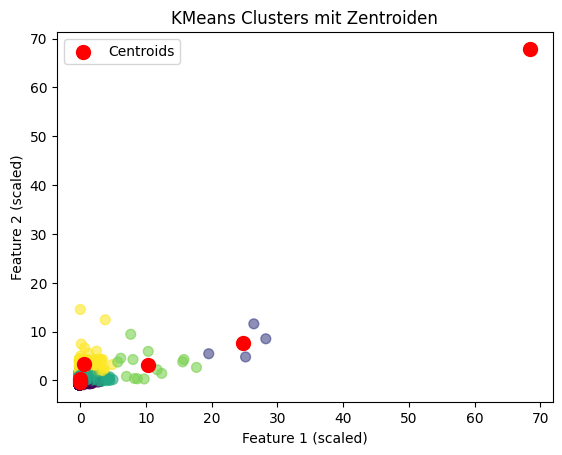

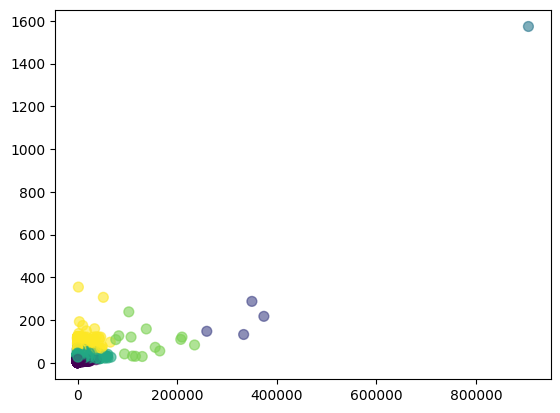

In [38]:
import numpy as np
from matplotlib import pyplot as plt


# X und y vorbereiten
X = new_df[['out_of_business_times','max_logins_in_1min']].fillna(0)


# Pipeline fitten
pipeline.fit(X)

# KMeans aus Pipeline holen
kmeans = pipeline.named_steps['kmeans']

# Clusterlabels holen
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

scaler = pipeline.named_steps["standardscaler"]
X_scaled = scaler.transform(X)

# Scatterplot der Datenpunkte
plt.scatter(X_scaled[:, 0], X_scaled[:,1], c=labels, cmap='viridis', alpha=0.6, s=50)

# Zentroiden plotten
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, marker='o', label='Centroids')

plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.title("KMeans Clusters mit Zentroiden")
plt.legend()
plt.show()

# PLot without scaling
plt.scatter(X['out_of_business_times'], X['max_logins_in_1min'], c=labels, cmap='viridis', alpha=0.6, s=50)

3. Calculate the kMeans++ error (with all features) for 1 to 10 clusters. Use the [elbow method](https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/) to determine the optimal number of clusters. Plot your results. You can use the [kneedle libary](https://pypi.org/project/kneed/). (3P)

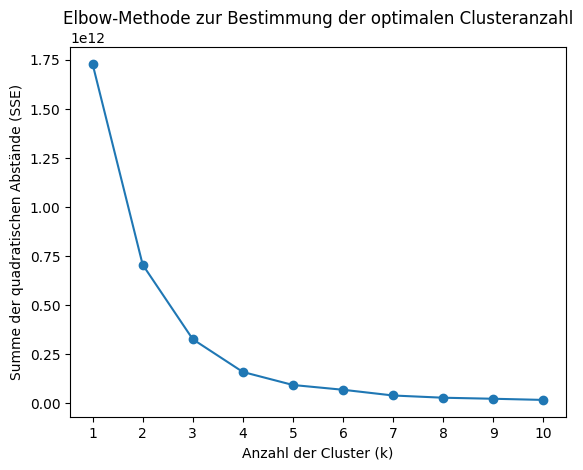

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from kneed import KneeLocator

# Elbow-Methode zur Bestimmung der optimalen Clusteranzahl
sse = []
K_range = range(1, 11)
for k in K_range:                   
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)         
# Plot der SSE-Werte
plt.plot(K_range, sse, marker='o')
plt.xlabel('Anzahl der Cluster (k)')
plt.ylabel('Summe der quadratischen Abstände (SSE)')
plt.title('Elbow-Methode zur Bestimmung der optimalen Clusteranzahl')
plt.xticks(K_range)
plt.show()

4. Use KMeans++ with the optimal numbers of clusters you determined above. Calculate the outliers based on the centroids. Outliers are datapoints with a higher standard deviation than the average data. Print the outliers as table and the percentage of outliers in comparison to the dataset. (3P)

In [29]:
# Fit KMeans
kmeans = KMeans(n_clusters=4, random_state=42).fit(X)

# Step 1: Get cluster centers
centroids = kmeans.cluster_centers_

X_np = X.values


# Step 2: Compute distances to nearest centroid
distances = np.min(
    np.linalg.norm(X_np[:, None] - centroids[None, :], axis=2),
    axis=1
)

#print(centroids.std())

# Step 3: Define threshold (mean + 2*std here)
threshold = distances.mean() + 2 * distances.std()

# Step 4: Identify outliers
outlier_mask = distances > threshold
outliers = X_np[outlier_mask]


print(outliers)

percentage_outliers = (len(outliers) / len(X_np)) * 100
print(f"Outliers: {percentage_outliers}%")


[[2.90890e+04 8.40000e+01]
 [2.25000e+04 7.00000e+00]
 [1.67290e+04 6.40000e+01]
 [9.91700e+03 1.40000e+01]
 [1.60660e+04 4.30000e+01]
 [1.51440e+04 3.00000e+01]
 [1.07050e+04 3.60000e+01]
 [1.22420e+04 2.30000e+01]
 [2.34969e+05 8.30000e+01]
 [2.39050e+04 2.80000e+01]
 [1.63830e+04 2.20000e+01]
 [1.83760e+04 3.60000e+01]
 [1.22660e+04 6.10000e+01]
 [1.26820e+04 4.60000e+01]
 [6.07870e+04 3.90000e+01]
 [2.24140e+04 1.70000e+01]
 [2.07318e+05 1.09000e+02]
 [1.57790e+04 1.10000e+01]
 [1.21590e+04 2.70000e+01]
 [9.43760e+04 4.10000e+01]
 [3.33546e+05 1.32000e+02]
 [1.11150e+04 3.10000e+01]
 [1.73490e+04 9.00000e+00]
 [3.74163e+05 2.17000e+02]
 [5.89340e+04 3.10000e+01]
 [2.63890e+04 1.70000e+01]
 [2.21060e+04 1.06000e+02]
 [1.78060e+04 2.30000e+01]
 [1.86750e+04 1.20000e+01]
 [1.10710e+04 1.80000e+01]
 [2.38760e+04 3.40000e+01]
 [1.33770e+04 2.10000e+01]
 [1.07030e+04 8.00000e+00]
 [1.04280e+04 1.74000e+02]
 [1.92340e+04 6.00000e+01]
 [1.90370e+04 7.00000e+00]
 [1.90360e+04 7.00000e+00]
 

5. Print the strongest outlier. (1P)

In [34]:

strongest_outlier = outliers[np.argmax(np.linalg.norm(outliers, axis=1))]
print("Strongest outlier:\n", strongest_outlier)

Strongest outlier:
 [3.74163e+05 2.17000e+02]


6. Provide one argument in favor and one against the conclusion that the determined outlier is a malicious user. (2P)

Against:
Outliers are measured by the centroids in this case representing certain behaviour of users. A deviation within a user group (cluster) does not constitute a malicious behaviour, much rather the cluster themselves need to be compared to determin benign/malicious behaviour.

In Favor:
It is an outlier within a group so worth further examination

7. Consider a realistic business scenario and provide one strategy, how to confirm an outlier as malicious actor? (1P)

Consider a company network. A good strategy would be to monitor user activity and block the user if suspicious behaviour occurs. Wait for Feedback and introduce a white list.